In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.decomposition import PCA

In [2]:
from pptoolbox.preprocessing import SNV, SavitzkyGolay
from pptoolbox.platform.preprocessor_constructor import construct_preprocessor_from_params
from pptoolbox.platform.module_preprocessor_defaults import MONITOR_PREPROCESSOR_DEFAULTS
from pptoolbox.monitor import MonitorTuner
from pptoolbox.visualization import plot_monitor_chart, plot_predictions_distribution, plot_spectra, plot_svp, spectral_vector_properties

# import data

In [ ]:
parent_dir = Path('../../data/processed')
version = 'v4'

data_dir = parent_dir / version

full_dir = data_dir / 'full' 
b4clean_dir = data_dir / '2026_jan_apr_b4fail'

In [4]:
X_full = pd.read_csv(b4clean_dir / 'input.csv', index_col=0)
y_full = pd.read_csv(b4clean_dir / 'label.csv', index_col=0)
meta_full = pd.read_csv(b4clean_dir / 'meta.csv', index_col=0)
print(X_full.shape, y_full.shape, meta_full.shape)

(1320, 191) (1320, 5) (1320, 7)


In [5]:
X_full

,480.0,483.0,486.0,489.0,492.0,495.0,498.0,501.0,504.0,507.0,...,1023.0,1026.0,1029.0,1032.0,1035.0,1038.0,1041.0,1044.0,1047.0,1050.0
lot_id,,,,,,,,,,,,,,,,,,,,,
116565,4.889579,4.884041,4.882357,4.877739,4.874928,4.888526,4.867299,4.885722,4.881102,4.902379,...,7.055322,7.114065,7.158727,7.209848,7.253015,7.293622,7.342960,7.379918,7.421705,7.441816
116565,5.001608,4.993344,4.971963,4.977503,4.961175,4.982146,4.980291,4.982958,4.975488,4.990298,...,7.173624,7.244866,7.319233,7.356794,7.407080,7.479915,7.514005,7.552201,7.619405,7.665687
116565,4.838713,4.829668,4.809810,4.812043,4.799558,4.810299,4.798972,4.808283,4.794459,4.798084,...,8.347037,8.410995,8.482535,8.523740,8.625107,8.683910,8.753469,8.822296,8.874640,8.888063
116565,4.886959,4.865844,4.863381,4.857259,4.849217,4.857771,4.847537,4.845987,4.841813,4.850230,...,8.056591,8.107440,8.202513,8.247615,8.347741,8.428176,8.501688,8.544762,8.599354,8.642742
116565,4.794660,4.784344,4.778843,4.776626,4.765114,4.770792,4.772958,4.766722,4.759092,4.769915,...,7.986632,8.034913,8.103151,8.162408,8.208268,8.284933,8.315700,8.348166,8.435143,8.426722
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
124952,5.013358,5.006111,5.000308,4.990082,4.984905,4.987331,4.991569,4.990247,4.985340,4.999302,...,7.533343,7.589764,7.647999,7.731775,7.784876,7.865954,7.915637,7.974201,7.997255,8.036115
124952,5.034930,5.017828,5.011344,5.004301,5.008927,5.024293,5.008601,5.012895,5.013792,5.029423,...,7.716532,7.776403,7.851000,7.925134,8.015186,8.102622,8.148991,8.236244,8.279925,8.334999
124952,4.945056,4.923682,4.916818,4.917799,4.908644,4.931223,4.923373,4.926692,4.924669,4.951224,...,7.782774,7.858421,7.908606,7.969006,8.075279,8.124127,8.170997,8.216326,8.287408,8.277275


In [6]:
X_full.isna().sum().sum()

0

# preprocessing

In [7]:
def apply_preprocessing(X, prepro_method):
    """
    Apply preprocessing to spectral data.
    
    Parameters:
    -----------
    X : pd.DataFrame
        NIR data
    prepro_method : str
        One of: 'NoPrepro', 'SNV', 'SG1D'
    
    Returns:
    --------
    dict : Contains X_plot, X_ex_plot, X_full_plot, and prepro name
    """
    
    if prepro_method == 'NoPrepro':
        return {
            'X_plot': X.copy(),
            'prepro': 'NoPrepro'
        }
    
    elif prepro_method == 'SNV':
        return {
            'X_plot': pd.DataFrame(SNV().fit_transform(X), index=X.index, columns=X.columns),
            'prepro': 'SNV'
        }
    
    elif prepro_method == 'SG1D':
        msc = SavitzkyGolay(deriv=1, window=9, polyorder=2)
        return {
            'X_plot': pd.DataFrame(msc.fit_transform(X), 
                                columns=X.columns[4:-4], index=X.index),
            'prepro': 'SG1D'
        }
    elif prepro_method == 'SG2D':
        msc = SavitzkyGolay(deriv=2, window=17, polyorder=3)
        return {
            'X_plot': pd.DataFrame(msc.fit_transform(X), 
                                columns=X.columns[8:-8], index=X.index),
            'prepro': 'SG2D'
        }
    
    else:
        raise ValueError(f"Unknown preprocessing method: {prepro_method}")


# Loop through all preprocessing methods
prepro_methods = [
    'NoPrepro', 
    'SNV', 
    'SG1D',
    # 'SG2D'
    ]
prepro_results = {}

for method in prepro_methods:
    prepro_results[method] = apply_preprocessing(X_full, method)
    print(f"✓ Applied {method} preprocessing")

✓ Applied NoPrepro preprocessing
✓ Applied SNV preprocessing
✓ Applied SG1D preprocessing


# plotting

In [ ]:
output_dir = Path('../../data/processed/v4/b4clean')
print(output_dir)

..\data\processed\v4\b4clean


In [9]:
viz_output_dir = output_dir / 'visualization'
viz_output_dir.mkdir(parents=True, exist_ok=True)
viz_output_dir

WindowsPath('../data/processed/v4/b4clean/visualization')

## checking for outliers


Processing: NoPrepro


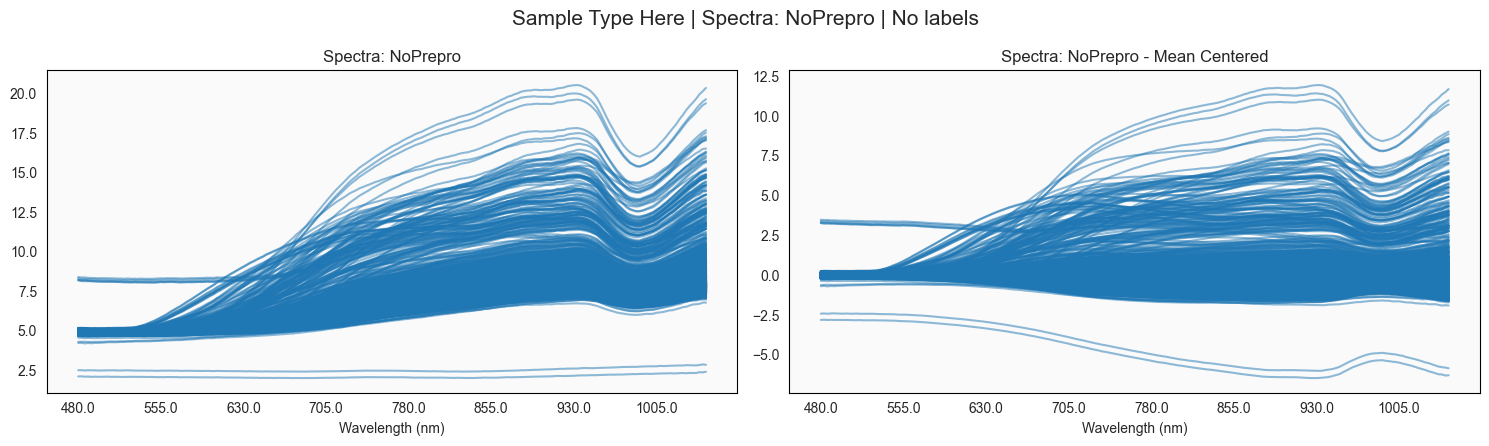

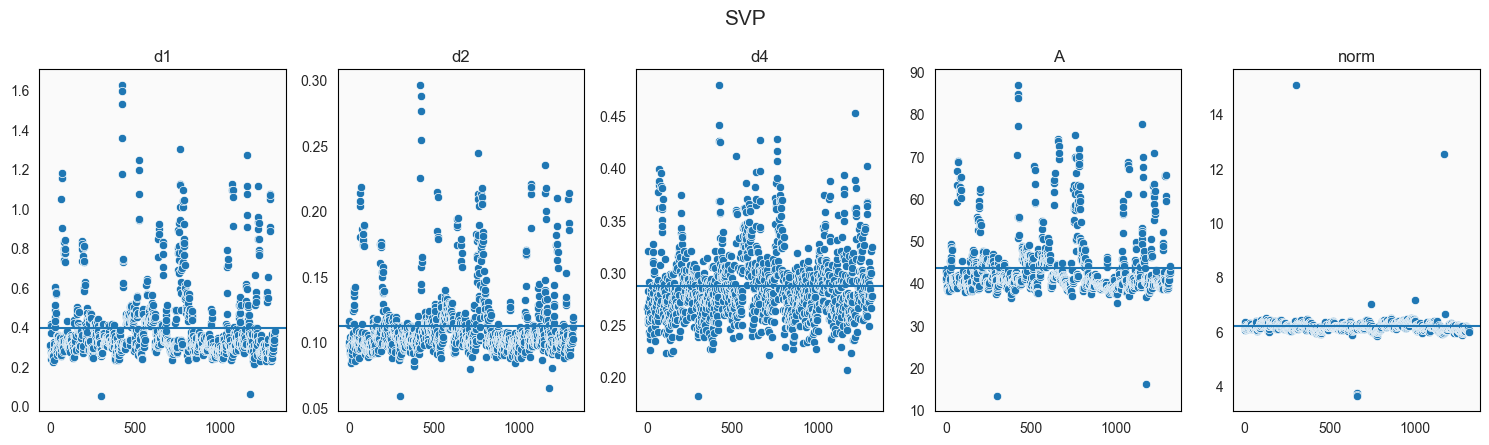


Processing: SNV


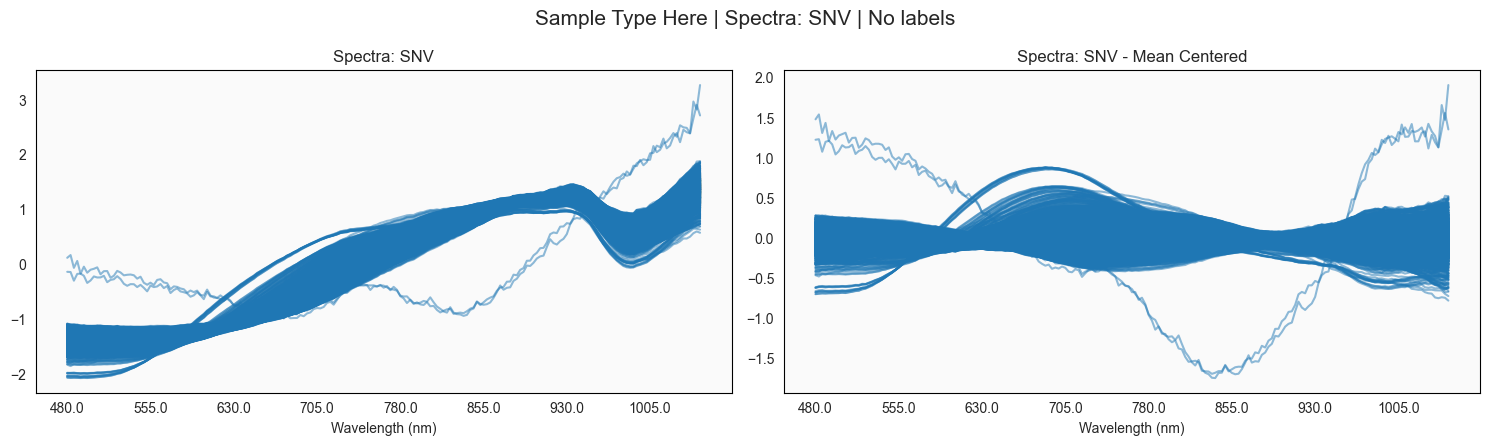


Processing: SG1D


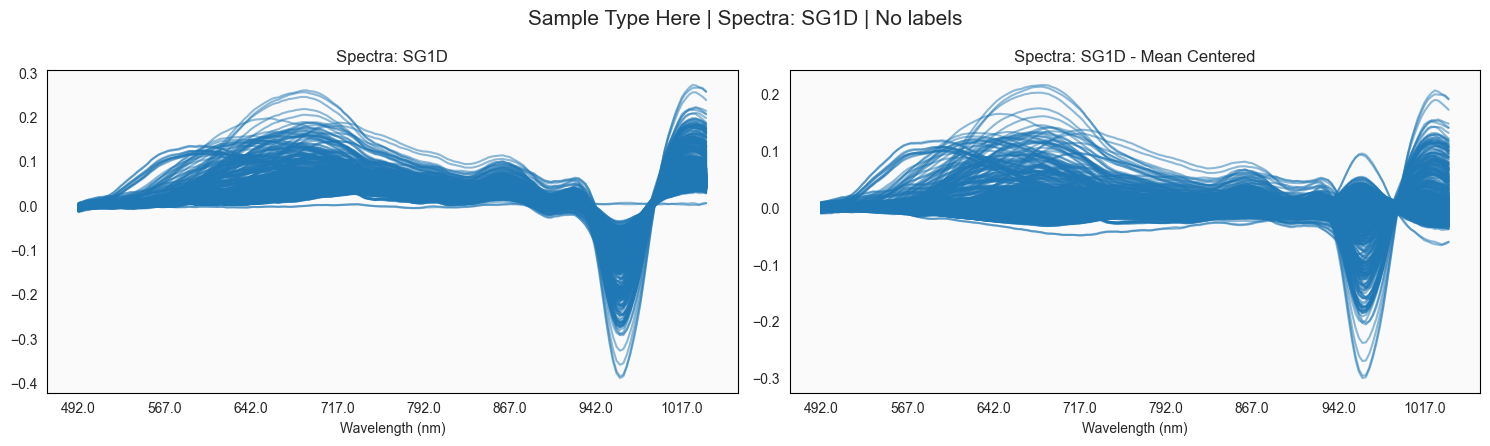

In [10]:
# Loop through all preprocessing methods for PCA plotting
for prepro_method in prepro_methods:
    print(f"\n{'='*60}")
    print(f"Processing: {prepro_method}")
    print(f"{'='*60}")
    
    # Get preprocessed data
    prepro_data = prepro_results[prepro_method]
    X_plot = prepro_data['X_plot']
    prepro = prepro_data['prepro']

    fig = plot_spectra(X_plot, spec_prep=prepro)
    plt.savefig(viz_output_dir / f'Spectra_{prepro}_b4clean.png', dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()

    if prepro_method != 'NoPrepro':
        continue  # Skip SVP for raw spectra as it may not be meaningful
    fig = plot_svp(X_plot)
    plt.savefig(viz_output_dir / f'svp_{prepro}_b4clean.png', dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()

In [21]:
df = spectral_vector_properties(X_full, return_df=True)
outlier_mask = (df['norm'] > 6.5) | (df['norm'] < 4.2)
outliers = df[outlier_mask]
outliers

,d1,d2,d4,A,norm
lot_id,,,,,
120880,0.050705,0.058999,0.181976,13.261141,15.071350
121562,0.829398,0.173558,0.367842,74.185779,3.706597
121562,0.812997,0.178762,0.426360,73.652772,3.728484
121562,0.769252,0.161683,0.341793,72.490587,3.732682
121562,0.660006,0.156810,0.343625,69.413634,3.661487
121562,0.700720,0.167785,0.397259,70.863258,3.625655
121641,0.312376,0.098657,0.265074,36.852674,7.018945
122388,0.270563,0.106761,0.293105,35.119458,7.167458
123544,0.057150,0.065045,0.206214,15.953768,12.508698


In [22]:
assert df.index.equals(X_full.index), "Index of SVP properties does not match index of X_full"

In [23]:
X_cleaned = X_full[~outlier_mask]
y_cleaned = y_full[~outlier_mask]
meta_cleaned = meta_full[~outlier_mask]

print (X_cleaned.shape, y_cleaned.shape, meta_cleaned.shape)

(1310, 191) (1310, 5) (1310, 7)


## check after removing

✓ Applied NoPrepro preprocessing
✓ Applied SNV preprocessing
✓ Applied SG1D preprocessing

Processing: NoPrepro


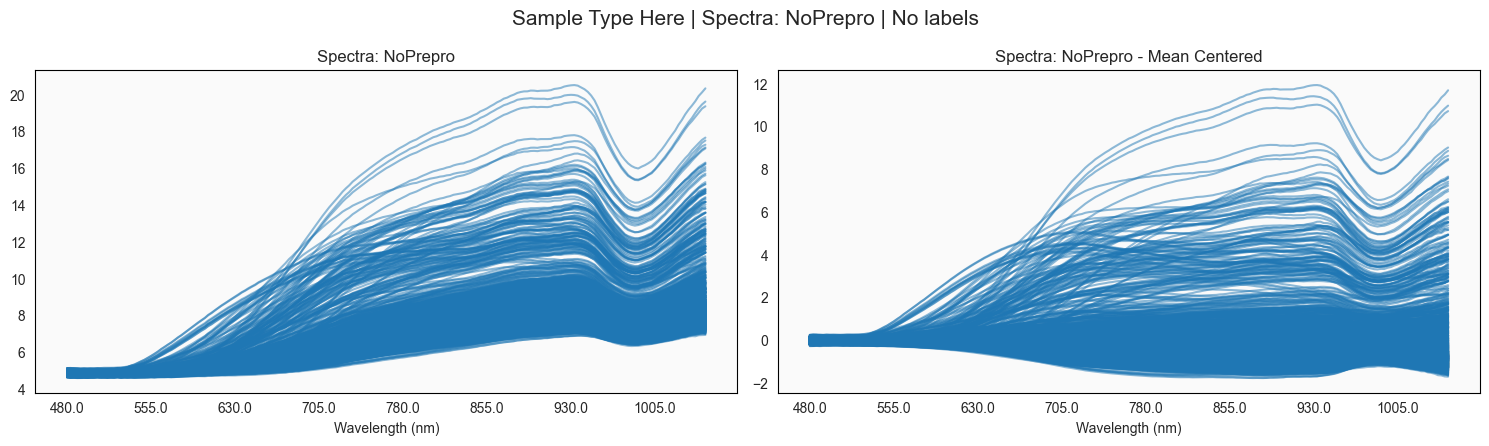

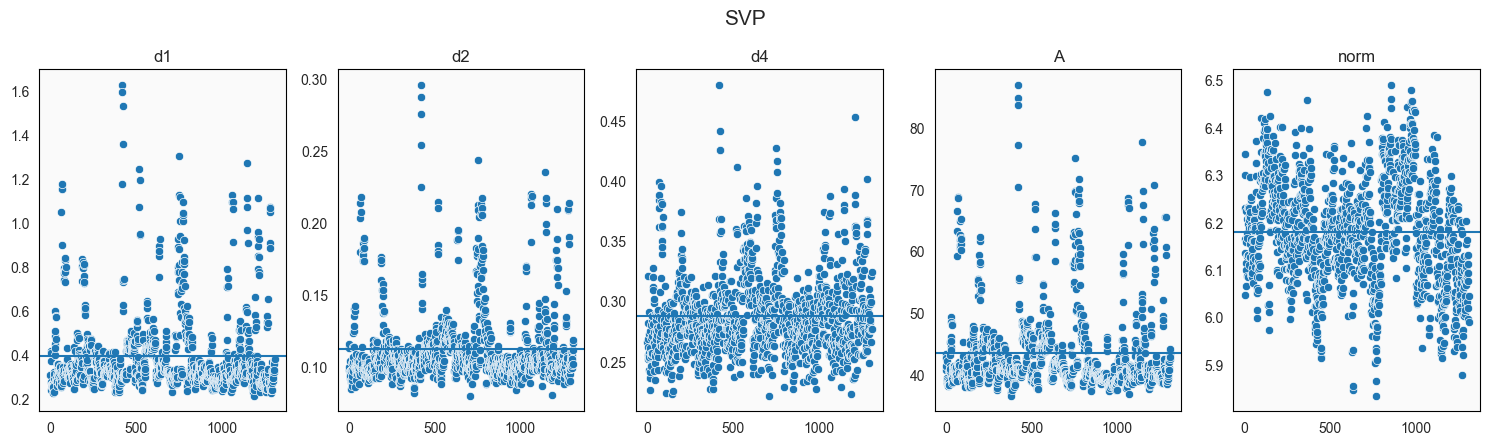


Processing: SNV


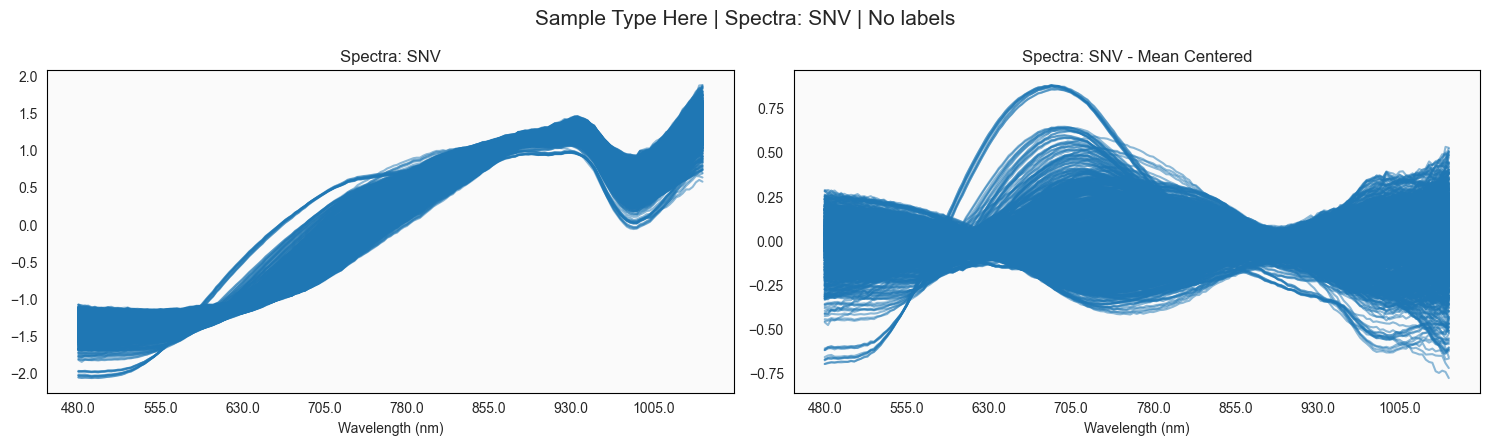


Processing: SG1D


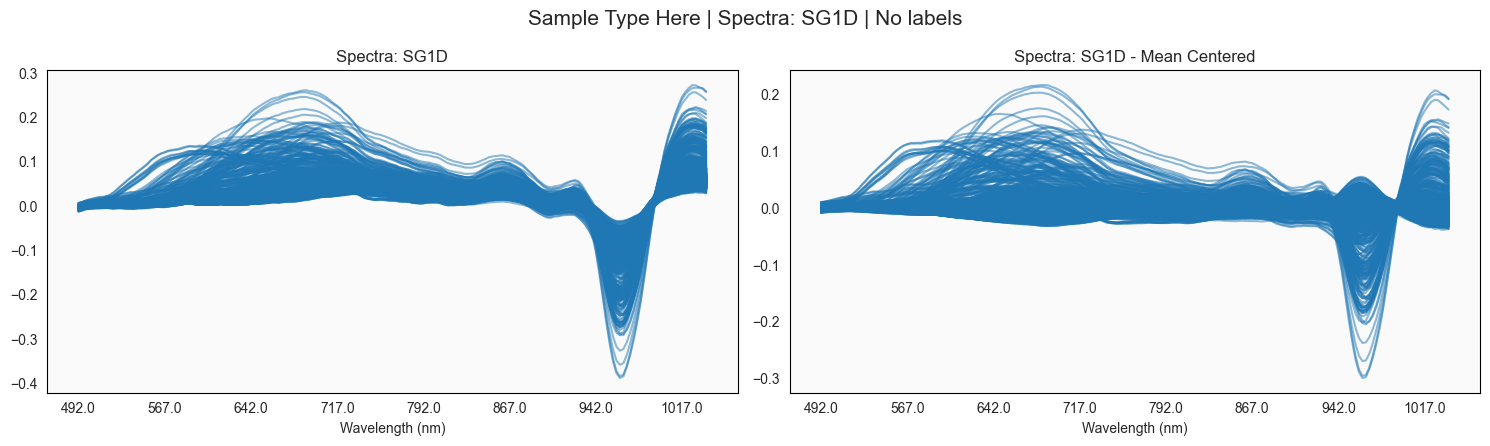

In [24]:
for method in prepro_methods:
    prepro_results[method] = apply_preprocessing(X_cleaned, method)
    print(f"✓ Applied {method} preprocessing")

# Loop through all preprocessing methods for PCA plotting
for prepro_method in prepro_methods:
    print(f"\n{'='*60}")
    print(f"Processing: {prepro_method}")
    print(f"{'='*60}")
    
    # Get preprocessed data
    prepro_data = prepro_results[prepro_method]
    X_plot = prepro_data['X_plot']
    prepro = prepro_data['prepro']

    fig = plot_spectra(X_plot, spec_prep=prepro)
    plt.savefig(viz_output_dir / f'Spectra_{prepro}_cleaned.png', dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()

    if prepro_method != 'NoPrepro':
        continue  # Skip SVP for raw spectra as it may not be meaningful
    fig = plot_svp(X_plot)
    plt.savefig(viz_output_dir / f'svp_{prepro}_cleaned.png', dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()

# run monitor to check for drift

In [ ]:
meta_cleaned['set'].value_counts()

In [ ]:
ref_mask = (meta_cleaned['set'] == 'original') | (meta_cleaned['set'] == 'calibration')
ref_mask

In [ ]:
X_ref = X_cleaned[ref_mask]
meta_ref = meta_cleaned[ref_mask]

X_check = X_cleaned[~ref_mask]
meta_check = meta_cleaned[~ref_mask]

In [ ]:
monitor_preprocessor = construct_preprocessor_from_params(MONITOR_PREPROCESSOR_DEFAULTS)
X_ref_prepro = pd.DataFrame(monitor_preprocessor.fit_transform(X_ref), index=X_ref.index)
X_check_prepro = pd.DataFrame(monitor_preprocessor.transform(X_check), index=X_check.index)

In [ ]:
monitor = MonitorTuner()
monitor.fit(X_ref_prepro)
pipeline = monitor.get_pipeline()

In [ ]:
X_ref_pred = pd.DataFrame(pipeline.predict(X_ref_prepro), index=X_ref_prepro.index)
X_check_pred = pd.DataFrame(pipeline.predict(X_check_prepro), index=X_check_prepro.index)

In [ ]:
X_ref_pred

In [ ]:
fig = plot_monitor_chart(
    train_preds = X_ref_pred, 
    # train_meta= meta_ref, 
    test_sets={"wh2026": X_check_pred},
    # test_metas={"wh2026": meta_check},
    palette = {"train": "steelblue", "wh2026": "coral"}
    )

# export cleaned dataset

In [28]:
output_dir = full_dir
output_dir.mkdir(parents=True, exist_ok=True)
print(output_dir)

..\data\processed\v4\full


In [29]:
X_cleaned.to_csv(output_dir / 'input.csv')
y_cleaned.to_csv(output_dir / 'label.csv')
meta_cleaned.to_csv(output_dir / 'meta.csv')